# Person Search Pipeline — YOLO26 + PersonViT on PRW

| ID         | Student        | Email                               |
|------------|----------------|-------------------------------------|
| 0001189110 | Rimondi Simone | simone.rimondi5@studio.unibo.it     |

## Overview

This notebook implements and evaluates the **two-stage person search pipeline** on the
**PRW** (*Person Re-identification in the Wild*) benchmark, combining the best models
identified in the separate ablation studies:

| Stage | Model | Weights file | Key metric |
|-------|-------|-------------|-----------|
| Detection | YOLO26-Large (Full FT) | `weights_detector/large_full_ft.pt` | mAP@0.5 = 96.24% |
| Re-ID | PersonViT ViT-Base (Full FT, Triplet) | `weights_reidentificator/vit_base_full_triplet.pth` | mAP = 85.65% |
| Re-ID (fallback) | PersonViT ViT-Small (Full FT, Triplet) | `weights_reidentificator/full_triplet.pth` | mAP = 81.50% |

> **ViT-Base weights** are stored via Git LFS. The notebook downloads them through the
> Git LFS Batch API (bypasses the raw CDN that serves only the pointer). If the download
> fails it falls back automatically to ViT-Small.

### Pipeline flow
```
Frame ──► YOLO26-Large ──► Detected crops ──► PersonViT ──► L2 embeddings
Query crop ──────────────────────────────────► PersonViT ──► L2 embedding
                                                                  │
                                               Cosine similarity ranking
                                                                  │
                                             eval_search_prw() ──► mAP, Top-1
```

### Platform
Designed to run on **Google Colab** (GPU runtime recommended — T4 or better).


## 1. Installation

In [1]:
# Install all required dependencies
!pip install -q ultralytics opencv-python-headless scipy
!pip install -q albumentations timm einops yacs pytorch-metric-learning thop tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 5.4 MB/s eta 0:00:00


## 2. Imports

In [2]:
import os
import sys
import copy
import math
import time
import json
import random
import zipfile
import requests
import urllib.request
from pathlib import Path

import cv2
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from ultralytics import YOLO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  WARNING: No GPU found. Running on CPU will be very slow.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda
  GPU : Tesla T4
  VRAM: 15.6 GB


## 3. Clone PersonViT Model Code

PersonViT is cloned from the personal fork `simoswish02/PersonViT`, which fixes
an import error present in the original upstream repo:
the implicit `from loss.metric_learning import ...` is replaced with the
fully-qualified `from transreid_pytorch.loss.metric_learning import ...`.


In [3]:
if not os.path.exists('PersonViT'):
    os.system('git clone https://github.com/simoswish02/PersonViT')
    print('PersonViT cloned successfully.')
else:
    print('PersonViT already present — skipping clone.')

sys.path.insert(0, 'PersonViT')

from transreid_pytorch.config import cfg as reid_cfg
from transreid_pytorch.model.make_model import make_model
print('TransReID imports OK.')

PersonViT cloned successfully.
TransReID imports OK.


## 4. Centralised Configuration

All paths, hyperparameters, and model choices live here.
**Edit `PRW_ROOT`** if you already have the dataset on disk or mounted from Drive.
`USE_VIT_BASE` is resolved automatically after the weight download.


In [4]:
class Config:
    # ── Dataset ────────────────────────────────────────────────────────────
    # Local path where PRW will be downloaded (or already exists).
    PRW_ROOT = '/content/PRW'

    # Kaggle public API URL — no authentication required for public datasets
    PRW_KAGGLE_URL = (
        'https://www.kaggle.com/api/v1/datasets/download/'
        'edoardomerli/prw-person-re-identification-in-the-wild'
    )

    # ── Model selection ────────────────────────────────────────────────────
    # Auto-set to True after download if vit_base weights are valid (> 80 MB).
    USE_VIT_BASE = False

    # Detector weights (YOLO26-Large, Full FT on PRW)
    DETECTOR_WEIGHTS = 'weights_detector/large_full_ft.pt'

    # Re-ID weights
    REID_WEIGHTS_SMALL = 'weights_reidentificator/full_triplet.pth'
    REID_WEIGHTS_BASE  = 'weights_reidentificator/vit_base_full_triplet.pth'

    # ── PersonViT architecture ─────────────────────────────────────────────
    VIT_SMALL_TYPE = 'vit_small_patch16_224_TransReID'
    VIT_BASE_TYPE  = 'vit_base_patch16_224_TransReID'
    VIT_SMALL_DIM  = 384
    VIT_BASE_DIM   = 768

    # ── Re-ID input resolution (must match training) ───────────────────────
    IMG_HEIGHT = 256
    IMG_WIDTH  = 128

    # ── Detection parameters ───────────────────────────────────────────────
    DET_IMG_SIZE    = 640
    # Low conf at inference: keep all candidates.
    # eval_search_prw applies its own det_thresh at evaluation time.
    DET_CONF_THRESH = 0.001
    DET_IOU_NMS     = 0.5

    # ── Evaluation ─────────────────────────────────────────────────────────
    DET_THRESH_SWEEP = [0.01, 0.1, 0.3, 0.5]
    IGNORE_CAM_ID    = True   # standard PRW protocol

    # ── DataLoader ─────────────────────────────────────────────────────────
    BATCH_SIZE  = 64
    NUM_WORKERS = 2   # keep low on Colab to avoid multiprocessing issues

    # ── Minimum bounding-box area (px²) to keep ────────────────────────────
    MIN_BOX_AREA = 100

    # ── Output ─────────────────────────────────────────────────────────────
    RESULTS_DIR = Path('./pipeline_results')
    SEED        = 42


cfg = Config()
cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Fix random seeds for reproducibility
random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)

print('Config ready.')
print(f'  PRW_ROOT    : {cfg.PRW_ROOT}')
print(f'  RESULTS_DIR : {cfg.RESULTS_DIR}')

Config ready.
  PRW_ROOT    : /content/PRW
  RESULTS_DIR : pipeline_results


## 5. Dataset Download — PRW via Kaggle Public API

The PRW dataset is publicly available on Kaggle and can be downloaded without
authentication using the Kaggle public API endpoint. The zip archive (~3.6 GB)
is streamed to disk and extracted once; subsequent runs skip the download if the
`frames/` folder already exists.


In [5]:
prw_zip = '/content/prw_dataset.zip'

if not os.path.exists(cfg.PRW_ROOT):
    print('Downloading PRW dataset from Kaggle...')
    urllib.request.urlretrieve(cfg.PRW_KAGGLE_URL, prw_zip)
    print('Extracting...')
    os.makedirs(cfg.PRW_ROOT, exist_ok=True)
    with zipfile.ZipFile(prw_zip, 'r') as z:
        z.extractall(cfg.PRW_ROOT)
    os.remove(prw_zip)
    print(f'PRW dataset ready at {cfg.PRW_ROOT}')
else:
    print(f'PRW dataset already present at {cfg.PRW_ROOT}')

# Verify expected structure
for sub in ['frames', 'annotations', 'query_box', 'query_info.txt',
            'frame_train.mat', 'frame_test.mat']:
    path = os.path.join(cfg.PRW_ROOT, sub)
    assert os.path.exists(path), f'Expected path not found: {path}'
print('PRW structure verified OK.')

Extracting...
PRW dataset ready at /content/PRW
PRW structure verified OK.


## 6. Download Model Weights

### Detector & ViT-Small
Standard files — downloaded directly from the GitHub raw CDN with `wget`.

### ViT-Base (Git LFS)
`vit_base_full_triplet.pth` is stored via **Git LFS**. The raw CDN only serves
the 134-byte LFS pointer text. The actual binary is retrieved in three steps:
1. Download the LFS pointer and parse the **OID** (SHA-256) and file size.
2. Call the **Git LFS Batch API** (`POST /<repo>.git/info/lfs/objects/batch`)
   to obtain a temporary download URL from the LFS storage backend.
3. Stream the binary from that URL to disk.

If the LFS download fails for any reason, `USE_VIT_BASE` stays `False` and
the pipeline falls back to ViT-Small automatically.


In [6]:
REPO_OWNER = 'simoswish02'
REPO_NAME  = 'PersonSearch-AssignmentML4CV'
REPO_RAW   = f'https://raw.githubusercontent.com/{REPO_OWNER}/{REPO_NAME}/main'

os.makedirs('weights_detector',        exist_ok=True)
os.makedirs('weights_reidentificator', exist_ok=True)


def download_direct(local_path, url, min_size=1_000):
    """Download a file via wget; skip if already present and large enough."""
    if os.path.exists(local_path) and os.path.getsize(local_path) > min_size:
        print(f'  [OK]  {local_path}  ({os.path.getsize(local_path)/1e6:.1f} MB) — skipped')
        return True
    print(f'  Downloading {local_path} ...')
    ret = os.system(f'wget -q --show-progress -O "{local_path}" "{url}"')
    if ret != 0 or not os.path.exists(local_path):
        print(f'  [ERROR] wget failed for {local_path}')
        return False
    sz = os.path.getsize(local_path)
    if sz < min_size:
        print(f'  [WARN] Only {sz} B — may be an LFS pointer')
        return False
    print(f'  [OK]  {local_path}  ({sz/1e6:.1f} MB)')
    return True


def parse_lfs_pointer(repo_owner, repo_name, file_path):
    """
    Fetch the raw LFS pointer from GitHub and extract (oid, size).
    Pointer format:
        version https://git-lfs.github.com/spec/v1
        oid sha256:<64-char-hex>
        size <bytes>
    """
    url  = f'https://raw.githubusercontent.com/{repo_owner}/{repo_name}/main/{file_path}'
    text = requests.get(url, timeout=10).text
    oid, size = None, None
    for line in text.splitlines():
        if line.startswith('oid sha256:'):
            oid = line.split(':')[1].strip()
        elif line.startswith('size '):
            size = int(line.split()[1])
    if oid is None or size is None:
        raise ValueError(f'Could not parse LFS pointer:\n{text}')
    print(f'  LFS pointer parsed → OID={oid[:16]}...  size={size/1e6:.1f} MB')
    return oid, size


def download_lfs_file(local_path, repo_owner, repo_name, lfs_oid, lfs_size,
                      min_size=80_000_000):
    """
    Download a Git LFS object via the LFS Batch API.
    No GitHub token required for public repositories.
    """
    if os.path.exists(local_path) and os.path.getsize(local_path) > min_size:
        print(f'  [OK]  {local_path}  ({os.path.getsize(local_path)/1e6:.1f} MB) — skipped')
        return True

    lfs_batch_url = (
        f'https://github.com/{repo_owner}/{repo_name}.git/info/lfs/objects/batch'
    )
    headers = {
        'Accept':       'application/vnd.git-lfs+json',
        'Content-Type': 'application/vnd.git-lfs+json',
    }
    payload = {
        'operation': 'download',
        'transfers': ['basic'],
        'objects':   [{'oid': lfs_oid, 'size': lfs_size}],
    }

    resp = requests.post(lfs_batch_url, json=payload, headers=headers, timeout=30)
    if resp.status_code != 200:
        print(f'  [ERROR] LFS batch API → HTTP {resp.status_code}: {resp.text[:200]}')
        return False

    obj = resp.json().get('objects', [{}])[0]
    if 'error' in obj:
        print(f'  [ERROR] LFS object error: {obj["error"]}')
        return False

    dl_href    = obj['actions']['download']['href']
    dl_headers = obj['actions']['download'].get('header', {})

    print(f'  Streaming LFS file from storage ...')
    with requests.get(dl_href, headers=dl_headers, stream=True, timeout=600) as r:
        r.raise_for_status()
        total      = int(r.headers.get('content-length', 0))
        downloaded = 0
        with open(local_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=65536):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    pct = downloaded / total * 100
                    print(f'\r  Progress: {pct:.1f}%  ({downloaded/1e6:.1f}/{total/1e6:.1f} MB)',
                          end='', flush=True)
    print()

    sz = os.path.getsize(local_path)
    if sz < min_size:
        print(f'  [WARN] File is only {sz} B — LFS download may have failed')
        return False
    print(f'  [OK]  {local_path}  ({sz/1e6:.1f} MB)')
    return True


# ── Download detector weights ──────────────────────────────────────────────
print('=== Detector Weights ===')
download_direct(
    'weights_detector/large_full_ft.pt',
    f'{REPO_RAW}/weights_detector/large_full_ft.pt',
)

# ── Download Re-ID ViT-Small (direct) ─────────────────────────────────────
print()
print('=== Re-ID Weights: ViT-Small ===')
download_direct(
    'weights_reidentificator/full_triplet.pth',
    f'{REPO_RAW}/weights_reidentificator/full_triplet.pth',
)

# ── Download Re-ID ViT-Base (Git LFS) ─────────────────────────────────────
print()
print('=== Re-ID Weights: ViT-Base (Git LFS) ===')
lfs_ok = False
try:
    oid, lfs_size = parse_lfs_pointer(
        REPO_OWNER, REPO_NAME,
        'weights_reidentificator/vit_base_full_triplet.pth',
    )
    lfs_ok = download_lfs_file(
        local_path   = 'weights_reidentificator/vit_base_full_triplet.pth',
        repo_owner   = REPO_OWNER,
        repo_name    = REPO_NAME,
        lfs_oid      = oid,
        lfs_size     = lfs_size,
    )
except Exception as e:
    print(f'  [WARN] LFS download error: {e}')

# ── Resolve which Re-ID model to use ──────────────────────────────────────
vit_base_path = cfg.REID_WEIGHTS_BASE
cfg.USE_VIT_BASE = (
    lfs_ok and
    os.path.exists(vit_base_path) and
    os.path.getsize(vit_base_path) > 80_000_000
)

if cfg.USE_VIT_BASE:
    REID_WEIGHTS    = cfg.REID_WEIGHTS_BASE
    REID_TRANS_TYPE = cfg.VIT_BASE_TYPE
    REID_EMB_DIM    = cfg.VIT_BASE_DIM
    reid_label      = 'PersonViT ViT-Base  (Full FT, Triplet) — mAP 85.65%'
else:
    REID_WEIGHTS    = cfg.REID_WEIGHTS_SMALL
    REID_TRANS_TYPE = cfg.VIT_SMALL_TYPE
    REID_EMB_DIM    = cfg.VIT_SMALL_DIM
    reid_label      = 'PersonViT ViT-Small (Full FT, Triplet) — mAP 81.50%'

print()
print('=== Selected Models ===')
print(f'  Detector : {cfg.DETECTOR_WEIGHTS}')
print(f'  Re-ID    : {reid_label}')
print(f'  Weights  : {REID_WEIGHTS}')

=== Detector Weights ===
  [OK]  weights_detector/large_full_ft.pt  (52.9 MB)

=== Re-ID Weights: ViT-Small ===
  [OK]  weights_reidentificator/full_triplet.pth  (88.2 MB)

=== Re-ID Weights: ViT-Base (Git LFS) ===
  LFS pointer parsed → OID=d435c8e54a0e2d9a...  size=346.1 MB
  Streaming LFS file from storage ...
  Progress: 100.0%  (346.1/346.1 MB)
  [OK]  weights_reidentificator/vit_base_full_triplet.pth  (346.1 MB)

=== Selected Models ===
  Detector : weights_detector/large_full_ft.pt
  Re-ID    : PersonViT ViT-Base  (Full FT, Triplet) — mAP 85.65%
  Weights  : weights_reidentificator/vit_base_full_triplet.pth


## 7. PRW Dataset Utilities

- `PRWGalleryDataset` — loads every test-split frame with its ground-truth boxes.
  The `img_prefix` attribute (= path to `frames/`) is required by `eval_search_prw`.
- `PRWQueryDataset` — loads pre-cropped query images from `query_box/`
  using `query_info.txt`.


In [7]:
class PRWGalleryDataset(Dataset):
    """
    Loads the PRW test split frame-by-frame.
    Each item exposes the full image path, GT boxes ([x1,y1,x2,y2]), and person IDs.
    img_prefix is required by eval_search_prw.
    """
    def __init__(self, root, min_box_area=100):
        self.root         = root
        self.frames_dir   = os.path.join(root, 'frames')
        self.ann_dir      = os.path.join(root, 'annotations')
        self.img_prefix   = self.frames_dir   # used by eval_search_prw
        self.min_box_area = min_box_area
        self.annotations  = []
        self._build(os.path.join(root, 'frame_test.mat'))
        print(f'[GALLERY] {len(self.annotations)} frames loaded.')

    def _load_filenames(self, split_mat_path):
        mat = scipy.io.loadmat(split_mat_path)
        key = [k for k in mat.keys() if not k.startswith('__')][0]
        out = []
        for item in mat[key].flatten():
            name = str(item[0]) if isinstance(item, np.ndarray) else str(item)
            ann  = name + '.jpg.mat'
            if os.path.exists(os.path.join(self.ann_dir, ann)):
                out.append(ann)
        return sorted(out)

    def _extract_cam_id(self, img_name):
        try:
            if img_name.startswith('c'):
                return int(img_name[1])
        except Exception:
            pass
        return 1

    def _build(self, split_file):
        for af in tqdm(self._load_filenames(split_file), desc='Loading gallery'):
            img_name = af.replace('.mat', '').replace('.jpg', '') + '.jpg'
            img_path = os.path.join(self.frames_dir, img_name)
            mat_path = os.path.join(self.ann_dir, af)
            if not os.path.exists(img_path):
                continue
            img = cv2.imread(img_path)
            if img is None:
                continue
            H, W = img.shape[:2]
            vb, vp = [], []
            mat_data = scipy.io.loadmat(mat_path)
            for box in mat_data.get('box_new', []):
                pid = int(box[0])
                x1  = max(0.0, float(box[1]))
                y1  = max(0.0, float(box[2]))
                w   = float(box[3])
                h   = float(box[4])
                x2  = min(W, x1 + w)
                y2  = min(H, y1 + h)
                if w > 1 and h > 1 and (x2 - x1) * (y2 - y1) >= self.min_box_area:
                    vb.append([x1, y1, x2, y2])
                    vp.append(pid)
            self.annotations.append({
                'img_name': img_name,
                'img_path': img_path,
                'boxes':    np.array(vb, dtype=np.float32) if vb else np.zeros((0, 4), dtype=np.float32),
                'pids':     np.array(vp, dtype=np.int32)   if vp else np.zeros((0,),  dtype=np.int32),
                'cam_id':   self._extract_cam_id(img_name),
                'height':   H,
                'width':    W,
            })

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        return self.annotations[idx]


class PRWQueryDataset(Dataset):
    """
    Loads pre-cropped query images from query_box/ using query_info.txt.
    Each item is one pedestrian crop with its person ID and camera ID.
    """
    def __init__(self, root):
        self.query_dir   = os.path.join(root, 'query_box')
        self.query_info  = os.path.join(root, 'query_info.txt')
        self.annotations = []
        self._load()
        print(f'[QUERY]   {len(self.annotations)} queries loaded.')

    def _extract_cam_id(self, img_name):
        try:
            if img_name.startswith('c'):
                return int(img_name[1])
        except Exception:
            pass
        return 1

    def _load(self):
        with open(self.query_info) as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 6:
                continue
            pid = int(parts[0])
            if pid == -2:
                continue
            orig_name = parts[5] + '.jpg'
            crop_name = f'{pid}_{orig_name}'
            crop_path = os.path.join(self.query_dir, crop_name)
            if not os.path.exists(crop_path):
                continue
            img = cv2.imread(crop_path)
            if img is None:
                continue
            ch, cw = img.shape[:2]
            self.annotations.append({
                'img_name': crop_name,
                'img_path': crop_path,
                'boxes':    np.array([[0, 0, cw, ch]], dtype=np.float32),
                'pids':     np.array([pid], dtype=np.int32),
                'cam_id':   self._extract_cam_id(orig_name),
            })

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        return self.annotations[idx]


gallery_dataset = PRWGalleryDataset(cfg.PRW_ROOT, min_box_area=cfg.MIN_BOX_AREA)
query_dataset   = PRWQueryDataset(cfg.PRW_ROOT)

print(f'\nDataset summary:')
print(f'  Gallery frames : {len(gallery_dataset)}')
print(f'  Query crops    : {len(query_dataset)}')

Loading gallery: 100%|██████████| 6112/6112 [00:53<00:00, 113.28it/s]


[GALLERY] 6112 frames loaded.
[QUERY]   2057 queries loaded.

Dataset summary:
  Gallery frames : 6112
  Query crops    : 2057


## 8. Model Initialisation

### 8.1 Detector — YOLO26-Large

In [8]:
detector = YOLO(cfg.DETECTOR_WEIGHTS)
print(f'Detector loaded: {cfg.DETECTOR_WEIGHTS}')

# Sanity check on a dummy black image
_dummy = np.zeros((640, 640, 3), dtype=np.uint8)
_res   = detector(_dummy, verbose=False)
print(f'Sanity check passed. Dummy output boxes: {len(_res[0].boxes)}')
del _dummy, _res

Detector loaded: weights_detector/large_full_ft.pt
Sanity check passed. Dummy output boxes: 0


### 8.2 Re-Identificator — PersonViT

The `make_model` factory (TransReID) builds the ViT backbone.
The classifier head is replaced with `nn.Identity()` to return raw embeddings.
`strict=False` tolerates the missing classifier key produced by that replacement.


In [9]:
def load_personvit(weights_path, transformer_type, embedding_dim, reid_cfg_obj):
    """
    Instantiate PersonViT and load fine-tuned weights.
    Classifier replaced with nn.Identity() → raw L2 embeddings at inference.
    """
    mc = copy.deepcopy(reid_cfg_obj)
    mc.MODEL.NAME             = 'transformer'
    mc.MODEL.TRANSFORMER_TYPE = transformer_type
    mc.MODEL.JPM              = False
    mc.MODEL.PRETRAIN_CHOICE  = 'self'   # load weights from PRETRAIN_PATH
    mc.MODEL.PRETRAIN_PATH    = weights_path
    mc.MODEL.FEAT_DIM         = embedding_dim
    mc.INPUT.SIZE_TRAIN       = [cfg.IMG_HEIGHT, cfg.IMG_WIDTH]
    mc.INPUT.SIZE_TEST        = [cfg.IMG_HEIGHT, cfg.IMG_WIDTH]
    mc.TEST.NECK_FEAT         = 'after'  # post-BNNeck embedding (best for retrieval)

    model = make_model(mc, num_class=1, camera_num=0, view_num=0)
    model.classifier = nn.Identity()

    ckpt  = torch.load(weights_path, map_location='cpu')
    state = ckpt.get('model_state_dict', ckpt)
    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing:
        print(f'  Missing keys    ({len(missing)}): {missing[:3]} ...')
    if unexpected:
        print(f'  Unexpected keys ({len(unexpected)}): {unexpected[:3]} ...')

    model = model.to(device)
    model.eval()
    return model


reid_model = load_personvit(
    weights_path     = REID_WEIGHTS,
    transformer_type = REID_TRANS_TYPE,
    embedding_dim    = REID_EMB_DIM,
    reid_cfg_obj     = reid_cfg,
)
total_p     = sum(p.numel() for p in reid_model.parameters())
trainable_p = sum(p.numel() for p in reid_model.parameters() if p.requires_grad)
print(f'\nRe-ID model loaded: {REID_WEIGHTS}')
print(f'  Architecture    : {REID_TRANS_TYPE}')
print(f'  Embedding dim   : {REID_EMB_DIM}')
print(f'  Total params    : {total_p/1e6:.1f} M')
print(f'  Trainable params: {trainable_p:,}')

using Transformer_type: vit_base_patch16_224_TransReID as a backbone
using stride: [16, 16], and patch number is num_y16 * num_x8
Loading pretrained model from weights_reidentificator/vit_base_full_triplet.pth
===========building transformer===========

Re-ID model loaded: weights_reidentificator/vit_base_full_triplet.pth
  Architecture    : vit_base_patch16_224_TransReID
  Embedding dim   : 768
  Total params    : 86.5 M
  Trainable params: 86,516,200


## 9. Stage 1 — Detection

YOLO26-Large runs on every gallery frame.
A very low confidence threshold (`0.001`) is used to maximise recall —
`eval_search_prw` filters detections with its own `det_thresh` at evaluation time,
so discarding candidates here would permanently penalise the score.

Column order in `gallery_dets`: **[x1, x2, y1, y2, score]** — this is the format
expected by `eval_search_prw` (different from YOLO's native `[x1, y1, x2, y2]`).


In [10]:
@torch.no_grad()
def run_detection(gallery_dataset, detector, img_size, conf_thresh, iou_nms):
    """
    Run YOLO26 on all gallery frames.

    Returns
    -------
    gallery_dets : list[np.ndarray]
        One array per frame, shape [N_det, 5].
        Columns: [x1, x2, y1, y2, score] — format expected by eval_search_prw.
    """
    gallery_dets = []
    for anno in tqdm(gallery_dataset.annotations, desc='Stage 1 — Detection'):
        results = detector(
            anno['img_path'],
            imgsz   = img_size,
            conf    = conf_thresh,
            iou     = iou_nms,
            classes = [0],     # class 0 = person
            verbose = False,
        )
        boxes = results[0].boxes
        if len(boxes) == 0:
            gallery_dets.append(np.zeros((0, 5), dtype=np.float32))
            continue

        xyxy  = boxes.xyxy.cpu().numpy()   # [N, 4]: x1 y1 x2 y2
        confs = boxes.conf.cpu().numpy()   # [N]

        # Reorder columns: [x1, x2, y1, y2, score] as expected by eval_search_prw
        det = np.stack([
            xyxy[:, 0],   # x1
            xyxy[:, 1],   # y1
            xyxy[:, 2],   # x2
            xyxy[:, 3],   # y2
            confs,        # score
        ], axis=1).astype(np.float32)
        gallery_dets.append(det)

    total_dets       = sum(len(d) for d in gallery_dets)
    frames_with_dets = sum(1 for d in gallery_dets if len(d) > 0)
    print(f'\nDetection complete.')
    print(f'  Frames processed : {len(gallery_dets)}')
    print(f'  Frames with dets : {frames_with_dets}  ({100*frames_with_dets/len(gallery_dets):.1f}%)')
    print(f'  Total detections : {total_dets}')
    print(f'  Avg dets / frame : {total_dets / max(len(gallery_dets), 1):.1f}')
    return gallery_dets


t0 = time.time()
gallery_dets = run_detection(
    gallery_dataset,
    detector,
    img_size    = cfg.DET_IMG_SIZE,
    conf_thresh = cfg.DET_CONF_THRESH,
    iou_nms     = cfg.DET_IOU_NMS,
)
det_time = time.time() - t0
print(f'  Wall-clock: {det_time:.1f} s  ({det_time / len(gallery_dets) * 1000:.1f} ms/frame)')

Stage 1 — Detection: 100%|██████████| 6112/6112 [03:01<00:00, 33.64it/s]


Detection complete.
  Frames processed : 6112
  Frames with dets : 6112  (100.0%)
  Total detections : 55901
  Avg dets / frame : 9.1
  Wall-clock: 181.7 s  (29.7 ms/frame)


## 10. Stage 2a — Re-ID Feature Extraction: Gallery

Each detected crop is:
1. Sliced from the frame using the `[x1, x2, y1, y2]` box coordinates.
2. Resized to `256 × 128` and normalised with ImageNet statistics.
3. Fed through PersonViT → L2-normalised embedding vector.

`gallery_feats` is a list of `[N_det_i × D]` arrays, one per gallery frame.


In [11]:
# Inference-time transform — identical to test_transform used during training
reid_transform = A.Compose([
    A.Resize(cfg.IMG_HEIGHT, cfg.IMG_WIDTH),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])


def crop_and_transform(img_bgr, box_x1y1x2y2):
    """
    Crop a detection from a BGR frame and apply the Re-ID transform.
    Box format: [x1, x2, y1, y2] — eval_search_prw column order.
    Returns a float32 tensor of shape [3, H, W].
    """
    x1, y1, x2, y2 = box_x1y1x2y2
    x1, y1 = int(max(0, x1)), int(max(0, y1))
    x2, y2 = int(x2), int(y2)
    crop = img_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        crop = np.zeros((cfg.IMG_HEIGHT, cfg.IMG_WIDTH, 3), dtype=np.uint8)
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    return reid_transform(image=crop_rgb)['image']


@torch.no_grad()
def extract_gallery_features(gallery_dataset, gallery_dets, reid_model,
                              emb_dim, batch_size=64):
    """
    Extract L2-normalised Re-ID embeddings for all gallery detections.
    Returns a list of [N_det_i, emb_dim] arrays (one per frame).
    """
    reid_model.eval()
    gallery_feats = []

    for anno, det in tqdm(
            zip(gallery_dataset.annotations, gallery_dets),
            total=len(gallery_dataset),
            desc='Stage 2a — Gallery features'):

        if len(det) == 0:
            gallery_feats.append(np.zeros((0, emb_dim), dtype=np.float32))
            continue

        img_bgr = cv2.imread(anno['img_path'])
        if img_bgr is None:
            gallery_feats.append(np.zeros((0, emb_dim), dtype=np.float32))
            continue

        # Build list of crop tensors for this frame
        crops = [crop_and_transform(img_bgr, box[:4]) for box in det]

        # Process in mini-batches to avoid GPU OOM on dense frames
        frame_feats = []
        for i in range(0, len(crops), batch_size):
            batch = torch.stack(crops[i:i + batch_size]).to(device)
            out   = reid_model(batch)
            feats = out[0] if isinstance(out, tuple) else out
            feats = F.normalize(feats, p=2, dim=1)
            frame_feats.append(feats.cpu().numpy())

        gallery_feats.append(np.vstack(frame_feats).astype(np.float32))

    total_feats = sum(len(f) for f in gallery_feats)
    print(f'\nGallery feature extraction complete.')
    print(f'  Total vectors : {total_feats}')
    print(f'  Embedding dim : {emb_dim}')
    return gallery_feats


t0 = time.time()
gallery_feats = extract_gallery_features(
    gallery_dataset, gallery_dets, reid_model,
    REID_EMB_DIM, batch_size=cfg.BATCH_SIZE,
)
feat_time = time.time() - t0
print(f'  Wall-clock: {feat_time:.1f} s')

Stage 2a — Gallery features: 100%|██████████| 6112/6112 [09:12<00:00, 11.07it/s]


Gallery feature extraction complete.
  Total vectors : 55901
  Embedding dim : 768
  Wall-clock: 552.1 s


## 11. Stage 2b — Re-ID Feature Extraction: Query

Query crops are pre-extracted by PRW — no detection step needed.
Same transform and L2 normalisation as the gallery.
Returns a list of 1-D arrays `[D]`, one per query (format expected by `eval_search_prw`).


In [12]:
@torch.no_grad()
def extract_query_features(query_dataset, reid_model, emb_dim, batch_size=64):
    """
    Extract L2-normalised Re-ID embeddings for all query crops.
    Returns a list of 1-D np.ndarray of shape [emb_dim], one per query.
    """
    reid_model.eval()
    crops = []
    for anno in query_dataset.annotations:
        img_bgr = cv2.imread(anno['img_path'])
        if img_bgr is None:
            crops.append(torch.zeros(3, cfg.IMG_HEIGHT, cfg.IMG_WIDTH))
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        crops.append(reid_transform(image=img_rgb)['image'])

    all_feats = []
    for i in tqdm(range(0, len(crops), batch_size), desc='Stage 2b — Query features'):
        batch = torch.stack(crops[i:i + batch_size]).to(device)
        out   = reid_model(batch)
        feats = out[0] if isinstance(out, tuple) else out
        feats = F.normalize(feats, p=2, dim=1)
        all_feats.append(feats.cpu().numpy())

    feats_cat = np.vstack(all_feats).astype(np.float32)   # [N_query, D]
    print(f'\nQuery feature extraction complete.')
    print(f'  Queries   : {len(feats_cat)}')
    print(f'  Embedding : {emb_dim}')
    # Return as list of 1-D arrays — format required by eval_search_prw
    return [feats_cat[i] for i in range(len(feats_cat))]


t0 = time.time()
query_box_feats = extract_query_features(
    query_dataset, reid_model, REID_EMB_DIM, batch_size=cfg.BATCH_SIZE,
)
qfeat_time = time.time() - t0
print(f'  Wall-clock: {qfeat_time:.1f} s')

Stage 2b — Query features: 100%|██████████| 33/33 [00:17<00:00,  1.92it/s]


Query feature extraction complete.
  Queries   : 2057
  Embedding : 768
  Wall-clock: 19.6 s


## 12. Evaluation Function

`eval_search_prw` (from `eval_function.py` in the repo) implements the standard
PRW person search protocol:
- Ranks gallery detections by cosine similarity for each query.
- A detection is a TP if IoU with the GT box exceeds an adaptive threshold.
- AP is penalised by detector recall rate (missed frames count against the score).
- Reports **mAP** and **Top-1 accuracy**.


In [13]:
if not os.path.exists('eval_function.py'):
    ret = os.system(
        f'wget -q -O eval_function.py '
        f'https://raw.githubusercontent.com/{REPO_OWNER}/{REPO_NAME}/main/eval_function.py'
    )
    if ret == 0:
        print('eval_function.py downloaded.')
    else:
        raise RuntimeError('Failed to download eval_function.py')
else:
    print('eval_function.py already present.')

from eval_function import eval_search_prw
print('eval_search_prw imported successfully.')

eval_function.py downloaded.
eval_search_prw imported successfully.


## 13. det_thresh Sweep

`det_thresh` controls the minimum detection score accepted during evaluation.
We sweep several values to find the operating point that maximises mAP.


In [14]:
sweep_results = {}

for det_thresh in cfg.DET_THRESH_SWEEP:
    print('\n' + '='*60)
    print(f'  det_thresh = {det_thresh}')
    print('='*60)
    t0  = time.time()
    ret = eval_search_prw(
        gallery_dataset = gallery_dataset,
        query_dataset   = query_dataset,
        gallery_dets    = gallery_dets,
        gallery_feats   = gallery_feats,
        query_box_feats = query_box_feats,
        det_thresh      = det_thresh,
        ignore_cam_id   = cfg.IGNORE_CAM_ID,
    )
    elapsed = time.time() - t0
    sweep_results[det_thresh] = {
        'mAP':    float(ret['mAP']),
        'top1':   float(ret['accs'][0]),
        'time_s': elapsed,
    }
    print(f'  mAP  : {ret["mAP"]*100:.2f}%   Top-1: {ret["accs"][0]*100:.2f}%   ({elapsed:.1f} s)')

print('\n' + '='*60)
print(f'  {"det_thresh":>12}  {"mAP (%)": >10}  {"Top-1 (%)": >10}')
best_thresh, best_map = None, -1.0
for t, v in sweep_results.items():
    flag = '  ← best' if v['mAP'] > best_map else ''
    if v['mAP'] > best_map:
        best_map, best_thresh = v['mAP'], t
    print(f'  {t:>12.3f}  {v["mAP"]*100:>10.2f}  {v["top1"]*100:>10.2f}{flag}')
print(f'\nBest det_thresh: {best_thresh}  →  mAP = {best_map*100:.2f}%')


  det_thresh = 0.01
search ranking:
  mAP = 80.40%
  top- 1 = 98.40%
  mAP  : 80.40%   Top-1: 98.40%   (328.5 s)

  det_thresh = 0.1
search ranking:
  mAP = 81.94%
  top- 1 = 97.91%
  mAP  : 81.94%   Top-1: 97.91%   (328.1 s)

  det_thresh = 0.3
search ranking:
  mAP = 81.09%
  top- 1 = 97.52%
  mAP  : 81.09%   Top-1: 97.52%   (311.6 s)

  det_thresh = 0.5
search ranking:
  mAP = 79.10%
  top- 1 = 97.18%
  mAP  : 79.10%   Top-1: 97.18%   (308.2 s)

    det_thresh     mAP (%)   Top-1 (%)
         0.010       80.40       98.40  ← best
         0.100       81.94       97.91  ← best
         0.300       81.09       97.52
         0.500       79.10       97.18

Best det_thresh: 0.1  →  mAP = 81.94%


## 14. Final Evaluation at Best Threshold

In [15]:
print('='*65)
print(f'FINAL EVALUATION  —  det_thresh = {best_thresh}')
print('='*65)

final_ret = eval_search_prw(
    gallery_dataset = gallery_dataset,
    query_dataset   = query_dataset,
    gallery_dets    = gallery_dets,
    gallery_feats   = gallery_feats,
    query_box_feats = query_box_feats,
    det_thresh      = best_thresh,
    ignore_cam_id   = cfg.IGNORE_CAM_ID,
)

mAP  = float(final_ret['mAP'])
top1 = float(final_ret['accs'][0])

arch_str = 'ViT-Base ' if cfg.USE_VIT_BASE else 'ViT-Small'
print()
print('┌──────────────────────────────────────────────────────────────┐')
print('│           PERSON SEARCH PIPELINE — FINAL RESULTS            │')
print('├──────────────────────────────────────────────────────────────┤')
print(f'│  Detector  : YOLO26-Large  (Full FT on PRW)                 │')
print(f'│  Re-ID     : PersonViT {arch_str}  (Full FT, TripletLoss)  │')
print(f'│  det_thresh: {best_thresh:<10}                                  │')
print('├──────────────────────────────────────────────────────────────┤')
print(f'│  mAP       : {mAP*100:>7.2f} %                                  │')
print(f'│  Top-1 Acc : {top1*100:>7.2f} %                                  │')
print('└──────────────────────────────────────────────────────────────┘')

# Save results to JSON
results_summary = {
    'detector':         'YOLO26-Large Full FT',
    'reid_model':       f'PersonViT {arch_str} Full FT Triplet',
    'detector_weights': cfg.DETECTOR_WEIGHTS,
    'reid_weights':     REID_WEIGHTS,
    'det_thresh_sweep': sweep_results,
    'best_det_thresh':  best_thresh,
    'final_mAP':        mAP,
    'final_top1':       top1,
    'det_wall_time_s':  det_time,
    'feat_wall_time_s': feat_time + qfeat_time,
}
out_json = cfg.RESULTS_DIR / 'pipeline_results.json'
with open(out_json, 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f'\nResults saved → {out_json}')

FINAL EVALUATION  —  det_thresh = 0.1
search ranking:
  mAP = 81.94%
  top- 1 = 97.91%

┌──────────────────────────────────────────────────────────────┐
│           PERSON SEARCH PIPELINE — FINAL RESULTS            │
├──────────────────────────────────────────────────────────────┤
│  Detector  : YOLO26-Large  (Full FT on PRW)                 │
│  Re-ID     : PersonViT ViT-Base   (Full FT, TripletLoss)  │
│  det_thresh: 0.1                                         │
├──────────────────────────────────────────────────────────────┤
│  mAP       :   81.94 %                                  │
│  Top-1 Acc :   97.91 %                                  │
└──────────────────────────────────────────────────────────────┘

Results saved → pipeline_results/pipeline_results.json


## 15. Visualisation

### 15.1 det_thresh Sweep — mAP & Top-1

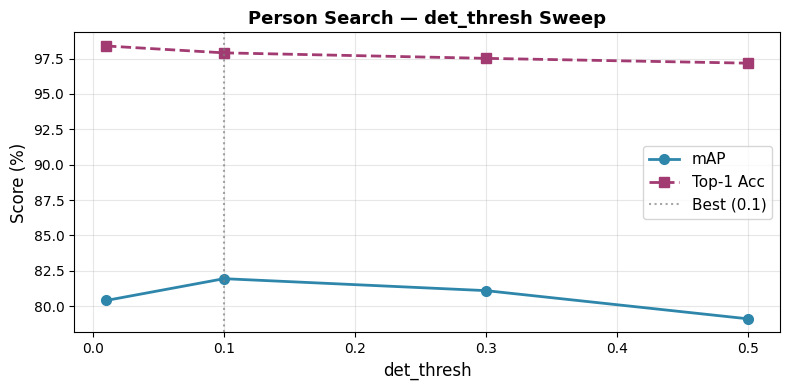

In [16]:
thresholds = list(sweep_results.keys())
maps  = [sweep_results[t]['mAP']  * 100 for t in thresholds]
top1s = [sweep_results[t]['top1'] * 100 for t in thresholds]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, maps,  'o-',  color='#2E86AB', lw=2, ms=7, label='mAP')
ax.plot(thresholds, top1s, 's--', color='#A23B72', lw=2, ms=7, label='Top-1 Acc')
ax.axvline(best_thresh, color='gray', linestyle=':', alpha=0.7,
           label=f'Best ({best_thresh})')
ax.set_xlabel('det_thresh', fontsize=12)
ax.set_ylabel('Score (%)',  fontsize=12)
ax.set_title('Person Search — det_thresh Sweep', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(cfg.RESULTS_DIR / 'thresh_sweep.png', dpi=150)
plt.show()

### 15.2 Detection Score Distribution

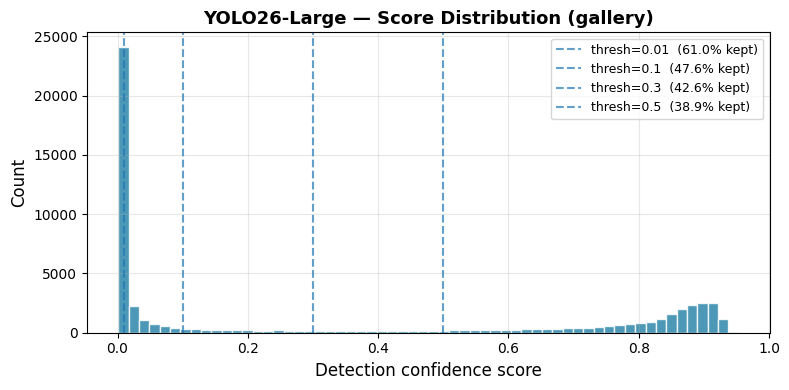

In [17]:
all_scores = np.concatenate([d[:, 4] for d in gallery_dets if len(d) > 0])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_scores, bins=60, color='#2E86AB', edgecolor='white', alpha=0.85)
for t in cfg.DET_THRESH_SWEEP:
    ax.axvline(t, linestyle='--', alpha=0.7,
               label=f'thresh={t}  ({(all_scores >= t).mean()*100:.1f}% kept)')
ax.set_xlabel('Detection confidence score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('YOLO26-Large — Score Distribution (gallery)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(cfg.RESULTS_DIR / 'score_distribution.png', dpi=150)
plt.show()

### 15.3 Qualitative: Top-5 Retrieved Matches per Query

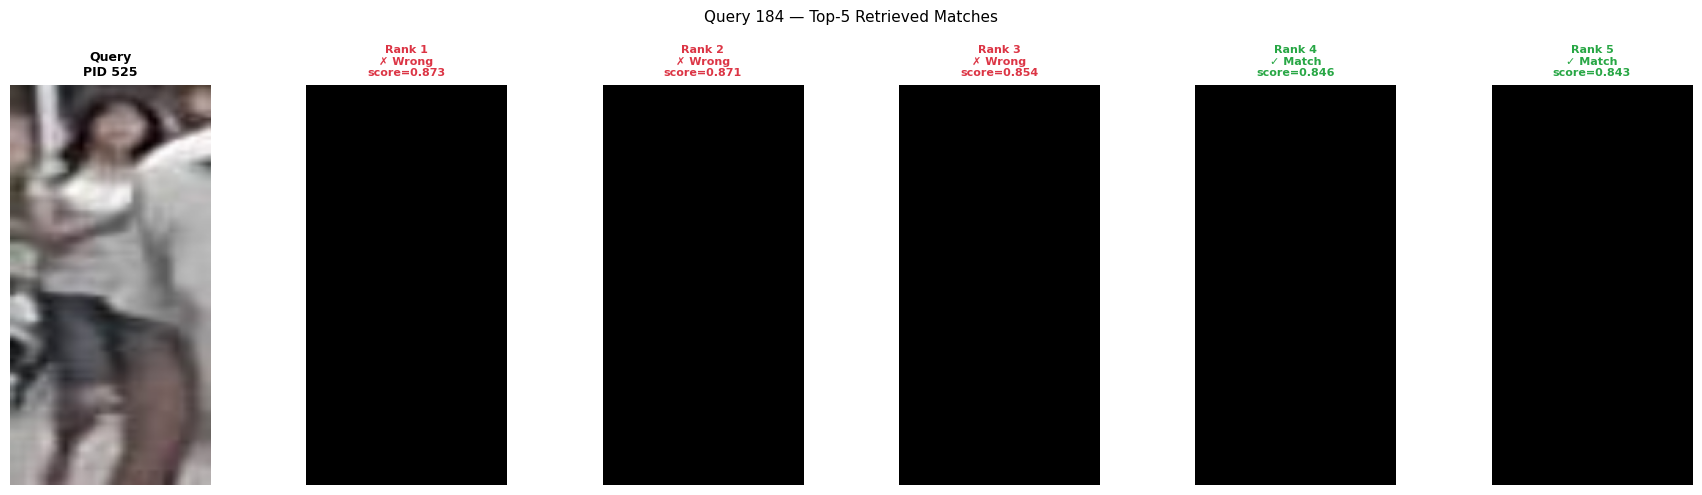

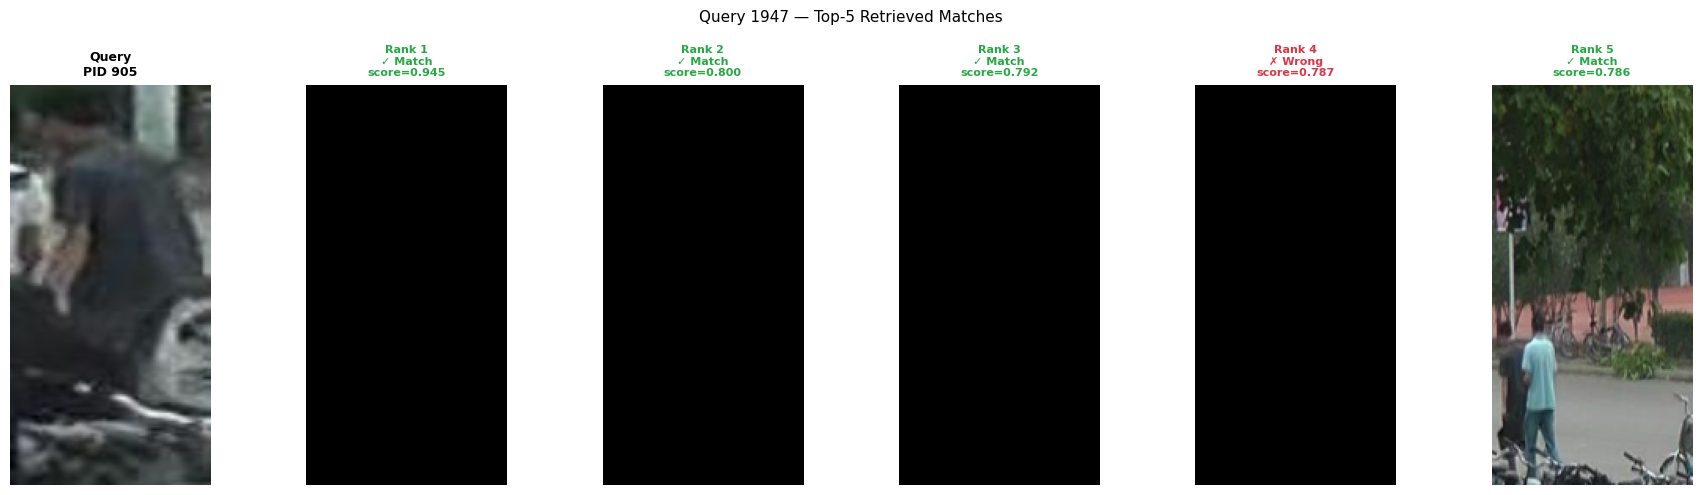

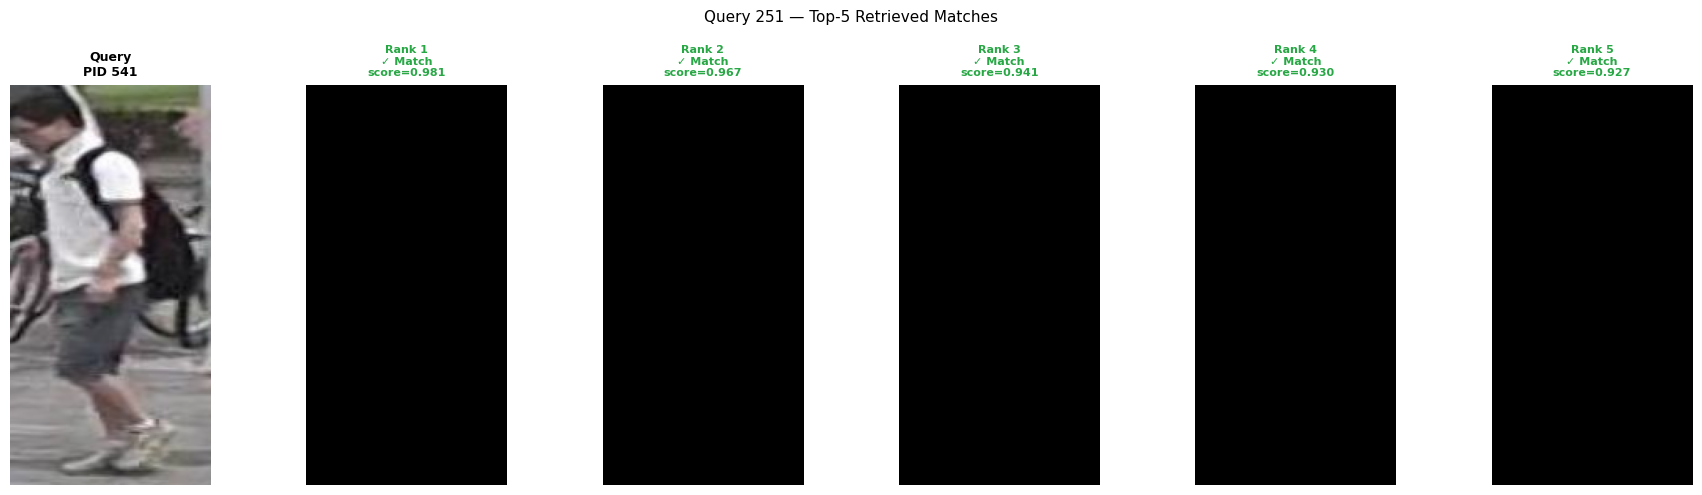

In [18]:
def visualise_query(query_idx, final_ret, query_dataset, gallery_dataset,
                    n_show=5, save_path=None):
    """
    Display the query crop alongside its top-N retrieved gallery detections.
    Green border = correct identity match, red = wrong.
    """
    entry  = final_ret['results'][query_idx]
    q_anno = query_dataset.annotations[query_idx]
    q_img  = cv2.cvtColor(cv2.imread(q_anno['img_path']), cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, n_show + 1, figsize=(3 * (n_show + 1), 5))
    axes[0].imshow(cv2.resize(q_img, (cfg.IMG_WIDTH, cfg.IMG_HEIGHT)))
    axes[0].set_title(f'Query\nPID {q_anno["pids"][0]}', fontsize=9, fontweight='bold')
    axes[0].axis('off')

    for k, item in enumerate(entry['gallery'][:n_show]):
        img_path = os.path.join(gallery_dataset.img_prefix, item['img'])
        img_bgr  = cv2.imread(img_path)
        if img_bgr is None:
            axes[k + 1].axis('off')
            continue

        # roi columns: [x1, x2, y1, y2, score]
        roi  = item['roi']
        crop = img_bgr[int(roi[2]):int(roi[3]), int(roi[0]):int(roi[1])]
        crop = cv2.cvtColor(crop if crop.size > 0
                            else np.zeros((cfg.IMG_HEIGHT, cfg.IMG_WIDTH, 3), np.uint8),
                            cv2.COLOR_BGR2RGB)

        color = '#28a745' if item['correct'] else '#dc3545'
        label = '✓ Match' if item['correct'] else '✗ Wrong'

        axes[k + 1].imshow(cv2.resize(crop, (cfg.IMG_WIDTH, cfg.IMG_HEIGHT)))
        axes[k + 1].set_title(
            f'Rank {k+1}\n{label}\nscore={item["score"]:.3f}',
            fontsize=8, color=color, fontweight='bold',
        )
        for spine in axes[k + 1].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        axes[k + 1].axis('off')

    plt.suptitle(f'Query {query_idx} — Top-{n_show} Retrieved Matches', fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


np.random.seed(cfg.SEED)
vis_idxs = np.random.choice(
    len(final_ret['results']),
    size=min(3, len(final_ret['results'])),
    replace=False,
)
for qi in vis_idxs:
    try:
        visualise_query(qi, final_ret, query_dataset, gallery_dataset,
                        n_show=5, save_path=cfg.RESULTS_DIR / f'query_vis_{qi}.png')
    except Exception as e:
        print(f'[WARNING] Query {qi}: {e}')

## 16. Pipeline Efficiency Summary

In [19]:
n_frames   = len(gallery_dataset)
n_queries  = len(query_dataset)
total_dets = sum(len(d) for d in gallery_dets)

print('='*62)
print('PIPELINE EFFICIENCY SUMMARY')
print('='*62)
print(f'  Gallery frames       : {n_frames}')
print(f'  Query crops          : {n_queries}')
print(f'  Total detections     : {total_dets}')
print(f'  Avg dets / frame     : {total_dets / n_frames:.1f}')
print()
print(f'  Stage 1  Detection   : {det_time:.1f} s  '
      f'({det_time / n_frames * 1000:.1f} ms/frame)')
print(f'  Stage 2a Gallery feat: {feat_time:.1f} s  '
      f'({feat_time / max(total_dets, 1) * 1000:.2f} ms/crop)')
print(f'  Stage 2b Query feat  : {qfeat_time:.1f} s  '
      f'({qfeat_time / n_queries * 1000:.2f} ms/query)')
print(f'  Total pipeline time  : {det_time + feat_time + qfeat_time:.1f} s')
print()
print(f'  ── Final Results ──────────────────────')
print(f'  mAP       : {mAP*100:.2f} %')
print(f'  Top-1 Acc : {top1*100:.2f} %')
print(f'  det_thresh: {best_thresh}')
print('='*62)

PIPELINE EFFICIENCY SUMMARY
  Gallery frames       : 6112
  Query crops          : 2057
  Total detections     : 55901
  Avg dets / frame     : 9.1

  Stage 1  Detection   : 181.7 s  (29.7 ms/frame)
  Stage 2a Gallery feat: 552.1 s  (9.88 ms/crop)
  Stage 2b Query feat  : 19.6 s  (9.52 ms/query)
  Total pipeline time  : 753.4 s

  ── Final Results ──────────────────────
  mAP       : 81.94 %
  Top-1 Acc : 97.91 %
  det_thresh: 0.1


## References

[1] Zheng et al. "Person Re-identification in the Wild." *CVPR* 2017.
https://arxiv.org/abs/1604.02531

[2] Ultralytics. "YOLO26." https://arxiv.org/abs/2509.25164

[3] Hu et al. "PersonViT: Large-scale Self-supervised Vision Transformer for Person Re-Identification."
*Machine Vision and Applications*, 2025. https://arxiv.org/abs/2408.05398

[4] He et al. "TransReID: Transformer-based Object Re-Identification." *ICCV* 2021.
https://arxiv.org/abs/2102.04378

[5] SeqNet eval_func — https://github.com/serend1p1ty/SeqNet/blob/master/eval_func.py
